<a href="https://colab.research.google.com/github/241b116-ishhhhhhhh/APS-LAB/blob/main/Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. Divide and Conquer (Sorting)

- **Created by Dr. Ajay

Write a python program to perform **Countingsort**.
* Statement:  Given a disordered list of repeated integers, rearrange the integers in natural order.
 Sample Input: [4,3,2,1,4,3,2,4,3,4]
 Sample Output: [1,2,2,3,3,3,4,4,4,4]

Time Complexity of Solution: Best Case O(n+k); Average Case O(n+k); Worst Case O(n+k), where n is the size of the input array and k means the values range from 0 to k.
- Approach:
Counting sort, like radix sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence counting sort is among the fastest sorting algorithms around, in theory. The  particular distinction for counting sort is that it creates a bucket for each value and keep a counter in each bucket. Then each time a value is encountered in the input collection, the appropriate counter is incremented. Because counting sort creates a bucket for each value, an imposing restriction is that the maximum value in the input array be known beforehand. Bucket sort uses a hash function to distribute values; counting sort, on the other hand, creates a counter for each value -- hence the name.
- Implementation notes:
1. Since the values range from 0 to k, create k+1 buckets.

2. To fill the buckets, iterate through the input list and
each time a value appears, increment the counter in its bucket.
3. Now fill the input list with the compressed data in the
buckets. Each bucket's key represents a value in the  array. So for each bucket, from smallest key to largest, add the index of the bucket to the input array and decrease the counter in said bucket by one; until the counter is zero.

Sample Input: [4, 3, 2, 1, 4, 3, 2, 4, 3, 4]
Sample Output: [1, 2, 2, 3, 3, 3, 4, 4, 4, 4]
Time taken 0.000112 seconds

Performance for Counting Sort and Python's built-in sort.
Size: 100, Counting Sort Time: 0.000107s, Timsort Time: 0.000013s
Size: 500, Counting Sort Time: 0.000126s, Timsort Time: 0.000054s
Size: 1000, Counting Sort Time: 0.000305s, Timsort Time: 0.000134s
Size: 2000, Counting Sort Time: 0.000684s, Timsort Time: 0.000459s
Size: 5000, Counting Sort Time: 0.001097s, Timsort Time: 0.000816s
Size: 10000, Counting Sort Time: 0.001273s, Timsort Time: 0.001674s
Size: 20000, Counting Sort Time: 0.002634s, Timsort Time: 0.003489s
Size: 50000, Counting Sort Time: 0.006937s, Timsort Time: 0.010811s


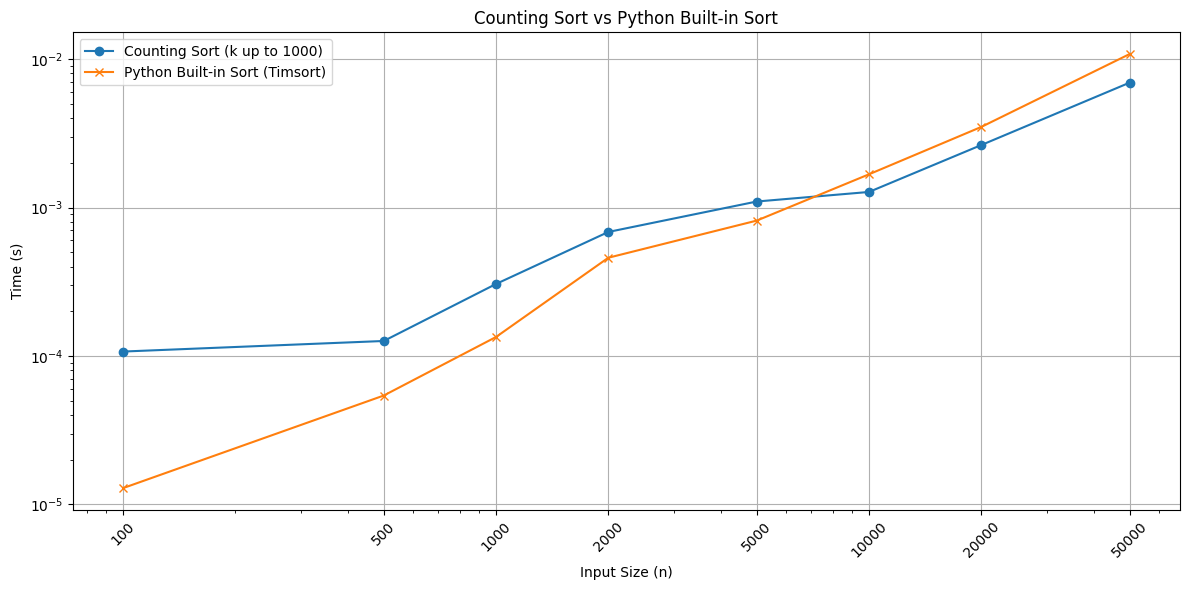

In [10]:
import time
import matplotlib.pyplot as plt
import random

def counting_sort(arr):
    if not arr:
        return []
    k = max(arr)
    count = [0] * (k + 1)
    for num in arr:
        count[num] += 1
    sorted_arr = []
    for i in range(k + 1):
        while count[i] > 0:
            sorted_arr.append(i)
            count[i] -= 1
    return sorted_arr
sample_input = [4, 3, 2, 1, 4, 3, 2, 4, 3, 4]
print(f"Sample Input: {sample_input}")
start_time = time.time()
sorted_sample = counting_sort(sample_input)
end_time = time.time()

print(f"Sample Output: {sorted_sample}")
print(f"Time taken {end_time - start_time:.6f} seconds")
def measure_time(sort_func, arr):
    start_time = time.time()
    sort_func(arr)
    end_time = time.time()
    return end_time - start_time

input_sizes = [100, 500, 1000, 2000, 5000, 10000, 20000, 50000]
ranges = [10, 50, 100, 200, 500]

counting_sort_times = []
timsort_times = []

print("\nPerformance for Counting Sort and Python's built-in sort.")
for size in input_sizes:
    max_val_for_test = 1000
    random_arr = [random.randint(0, max_val_for_test) for _ in range(size)]
    counting_sort_times.append(measure_time(counting_sort, list(random_arr)))
    timsort_times.append(measure_time(lambda x: x.sort(), list(random_arr)))

    print(f"Size: {size}, Counting Sort Time: {counting_sort_times[-1]:.6f}s, Timsort Time: {timsort_times[-1]:.6f}s")
plt.figure(figsize=(12, 6))
plt.plot(input_sizes, counting_sort_times, marker='o', label='Counting Sort (k up to 1000)')
plt.plot(input_sizes, timsort_times, marker='x', label='Python Built-in Sort (Timsort)')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (s)')
plt.title('Counting Sort vs Python Built-in Sort')
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.yscale('log')
plt.xticks(input_sizes, labels=[str(s) for s in input_sizes], rotation=45)
plt.tight_layout()
plt.show()

 - *Bucketsort*
Statement:
Given a disordered list of integers, rearrange them in natural order.
 Sample Input: [8,5,3,1,9,6,0,7,4,2,5]
 Sample Output: [0,1,2,3,4,5,6,7,8,9,5]
Time Complexity of Solution:
Best Case O(n); Average Case O(n); Worst Case O(n).
- Approach:
If it sounds too good to be true, then most likely it's not true. Bucketsort is not an exception to this adage. For bucketsort to
work at its blazing efficiency, there are multiple prerequisites.
First the hash function that is used to partition the elements need
to be very good and must produce ordered hash: if i < k then
hash(i) < hash(k). Second, the elements to be sorted must be
uniformly distributed.
  The aforementioned aside, bucket sort is actually very good
considering that counting sort is reasonably speaking its upper
bound. And counting sort is very fast. The particular distinction
for bucket sort is that it uses a hash function to partition the
keys of the input array, so that multiple keys may hash to the same
bucket. Hence each bucket must effectively be a growable list;
similar to radix sort.


Sample Input: [8, 5, 3, 1, 9, 6, 0, 7, 4, 2, 5]
Sample Output: [0, 1, 2, 3, 4, 5, 5, 6, 7, 8, 9]
Time taken for sample input: 0.000108 seconds

Performance for Bucket Sort and Python's built-in sort...
Size: 100, Bucket Sort Time: 0.000076s, Timsort Time: 0.000015s
Size: 500, Bucket Sort Time: 0.000233s, Timsort Time: 0.000065s
Size: 1000, Bucket Sort Time: 0.000516s, Timsort Time: 0.000158s
Size: 2000, Bucket Sort Time: 0.000626s, Timsort Time: 0.000269s
Size: 5000, Bucket Sort Time: 0.001591s, Timsort Time: 0.000901s
Size: 10000, Bucket Sort Time: 0.004357s, Timsort Time: 0.002144s
Size: 20000, Bucket Sort Time: 0.007167s, Timsort Time: 0.004251s
Size: 50000, Bucket Sort Time: 0.032082s, Timsort Time: 0.019182s


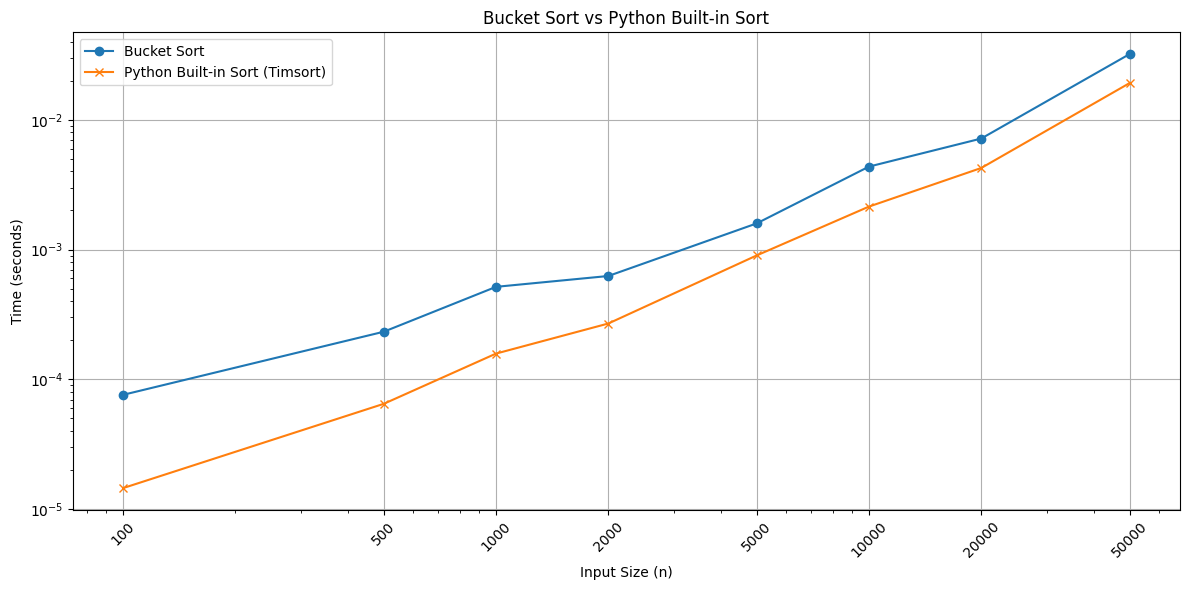

In [14]:
#write code for above cell and compute the running time and also plot graph.
import time
import matplotlib.pyplot as plt
import random

def bucket_sort(arr):
    if not arr:
        return []
    min_val = min(arr)
    max_val = max(arr)
    if min_val == max_val:
        return arr
    num_buckets = len(arr) // 2 or 1
    if num_buckets > 100:
        num_buckets = 100
    if max_val - min_val < num_buckets:
        num_buckets = max_val - min_val + 1
        if num_buckets == 0:
            return arr
    buckets = [[] for _ in range(num_buckets)]
    if max_val == min_val:
        bucket_range = 1
    else:
        bucket_range = (max_val - min_val + 1) / num_buckets
    for num in arr:
        if max_val == min_val:
            bucket_index = 0
        else:
            bucket_index = int((num - min_val) / bucket_range)
            if bucket_index >= num_buckets:
                bucket_index = num_buckets - 1
        buckets[bucket_index].append(num)
    sorted_arr = []
    for bucket in buckets:
        bucket.sort()
        sorted_arr.extend(bucket)
    return sorted_arr
sample_input = [8, 5, 3, 1, 9, 6, 0, 7, 4, 2, 5]
print(f"Sample Input: {sample_input}")
start_time = time.time()
sorted_sample = bucket_sort(sample_input)
end_time = time.time()

print(f"Sample Output: {sorted_sample}")
print(f"Time taken for sample input: {end_time - start_time:.6f} seconds")
def measure_time(sort_func, arr):
    start_time = time.time()
    sort_func(arr)
    end_time = time.time()
    return end_time - start_time

input_sizes = [100, 500, 1000, 2000, 5000, 10000, 20000, 50000]

bucket_sort_times = []
timsort_times = []
print("\nPerformance for Bucket Sort and Python's built-in sort...")
for size in input_sizes:
    max_val_for_test = size * 2
    random_arr = [random.randint(0, max_val_for_test) for _ in range(size)]
    bucket_sort_times.append(measure_time(bucket_sort, list(random_arr)))
    timsort_times.append(measure_time(lambda x: x.sort(), list(random_arr)))

    print(f"Size: {size}, Bucket Sort Time: {bucket_sort_times[-1]:.6f}s, Timsort Time: {timsort_times[-1]:.6f}s")
plt.figure(figsize=(12, 6))
plt.plot(input_sizes, bucket_sort_times, marker='o', label='Bucket Sort')
plt.plot(input_sizes, timsort_times, marker='x', label='Python Built-in Sort (Timsort)')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (seconds)')
plt.title('Bucket Sort vs Python Built-in Sort')
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.yscale('log')
plt.xticks(input_sizes, labels=[str(s) for s in input_sizes], rotation=45)
plt.tight_layout()
plt.show()

**Radix sort**
Statement:Given a disordered list of integers, rearrange them in natural order.
Sample Input: [18,5,100,3,1,19,6,0,7,4,2]
Sample Output: [0,1,2,3,4,5,6,7,18,19,100]
Time Complexity of Solution:Best Case O(kn); Average Case O(kn); Worst Case O(kn),where k is the length of the longest number and n is the size of the input array.Note: if k is greater than log(n) then an nlog(n) algorithm would be a better fit. In reality we can always change the radix to make k less than log(n).
- Approach: radix sort, like counting sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence radix sort is among the fastest sorting algorithms around, in theory. The particular distinction for radix sort is that it creates a bucket for each cipher (i.e. digit); as such, similar to bucket sort, each bucket in radix sort must be a
growable list that may admit different keys. For decimal values, the number of buckets is 10, as the decimal system has 10 numerals/cyphers (i.e. 0,1,2,3,4,5,6,7,8,9). Then the keys are continuously sorted by significant digits.

Sample Input: [18, 5, 100, 3, 1, 19, 6, 0, 7, 4, 2]
Sample Output: [0, 1, 2, 3, 4, 5, 6, 7, 18, 19, 100]
Time taken for sample input: 0.000098 seconds

Performance for Radix Sort and Python's built-in sort...
Size: 100, Radix Sort Time: 0.000159s, Timsort Time: 0.000012s
Size: 500, Radix Sort Time: 0.001023s, Timsort Time: 0.000055s
Size: 1000, Radix Sort Time: 0.001722s, Timsort Time: 0.000121s
Size: 2000, Radix Sort Time: 0.004246s, Timsort Time: 0.000277s
Size: 5000, Radix Sort Time: 0.010013s, Timsort Time: 0.000952s
Size: 10000, Radix Sort Time: 0.022596s, Timsort Time: 0.001687s
Size: 20000, Radix Sort Time: 0.043340s, Timsort Time: 0.003746s
Size: 50000, Radix Sort Time: 0.217722s, Timsort Time: 0.016773s


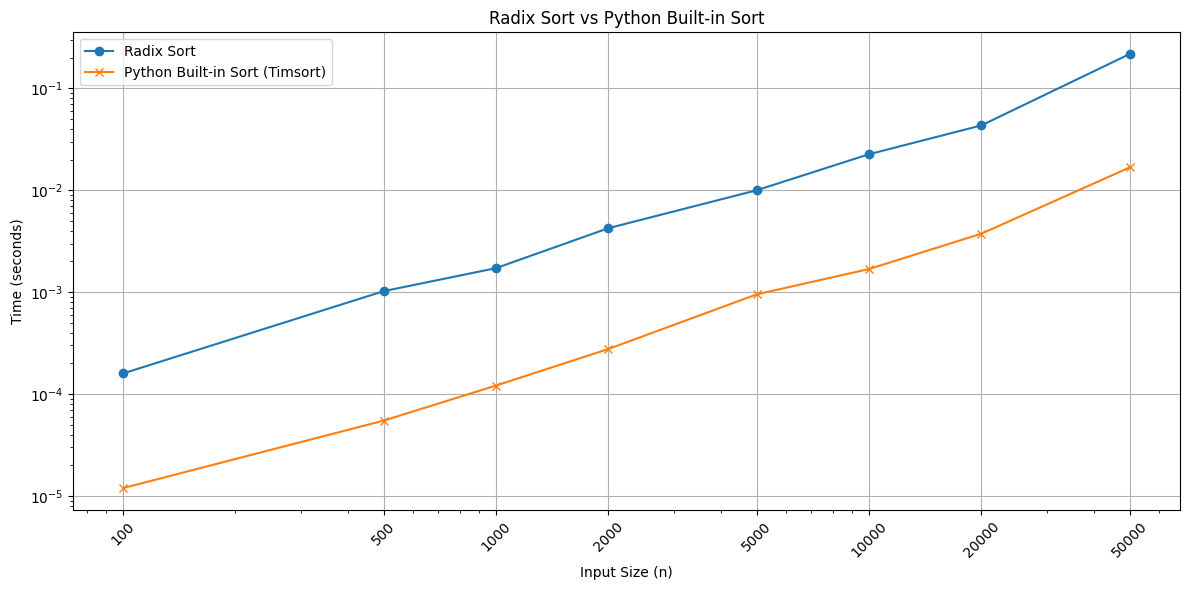

In [18]:
import time
import matplotlib.pyplot as plt
import random

def counting_sort_for_radix(arr, exp):
    n = len(arr)
    output = [0] * n
    count = [0] * 10
    for i in range(n):
        index = arr[i] // exp
        count[index % 10] += 1
    for i in range(1, 10):
        count[i] += count[i - 1]
    i = n - 1
    while i >= 0:
        index = arr[i] // exp
        output[count[index % 10] - 1] = arr[i]
        count[index % 10] -= 1
        i -= 1
    for i in range(n):
        arr[i] = output[i]

def radix_sort(arr):
    if not arr:
        return []
    max_val = max(arr)
    exp = 1
    while max_val // exp > 0:
        counting_sort_for_radix(arr, exp)
        exp *= 10
    return arr
sample_input = [18, 5, 100, 3, 1, 19, 6, 0, 7, 4, 2]
print(f"Sample Input: {sample_input}")
start_time = time.time()
sorted_sample = radix_sort(list(sample_input))
end_time = time.time()

print(f"Sample Output: {sorted_sample}")
print(f"Time taken for sample input: {end_time - start_time:.6f} seconds")

def measure_time(sort_func, arr):
    start_time = time.time()
    sort_func(arr)
    end_time = time.time()
    return end_time - start_time
input_sizes = [100, 500, 1000, 2000, 5000, 10000, 20000, 50000]

radix_sort_times = []
timsort_times = []

print("\nPerformance for Radix Sort and Python's built-in sort...")
for size in input_sizes:
    max_val_for_test = 100000
    random_arr = [random.randint(0, max_val_for_test) for _ in range(size)]
    radix_sort_times.append(measure_time(radix_sort, list(random_arr)))
    timsort_times.append(measure_time(lambda x: x.sort(), list(random_arr)))
    print(f"Size: {size}, Radix Sort Time: {radix_sort_times[-1]:.6f}s, Timsort Time: {timsort_times[-1]:.6f}s")
plt.figure(figsize=(12, 6))
plt.plot(input_sizes, radix_sort_times, marker='o', label='Radix Sort')
plt.plot(input_sizes, timsort_times, marker='x', label='Python Built-in Sort (Timsort)')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (seconds)')
plt.title('Radix Sort vs Python Built-in Sort')
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.yscale('log')
plt.xticks(input_sizes, labels=[str(s) for s in input_sizes], rotation=45)
plt.tight_layout()
plt.show()